# Pneumonia Detection — Phase 1: Data Pipeline

This notebook covers only the data pipeline:
1. Download the dataset from Kaggle
2. Fix the train/validation split
3. Set up data augmentation
4. Compute class weights to handle imbalance

No model training happens here — we're just making sure the data feeding into the model is clean and correct.

In [1]:
import os

# Walk the input directory to find the actual structure
for root, dirs, files in os.walk('/kaggle/input'):
    # Only print directory names, not files
    level = root.replace('/kaggle/input', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level > 3:  # don't go too deep
        break

input/
  datasets/
    paultimothymooney/
      chest-xray-pneumonia/
        chest_xray/


## Step 1: Count Images in Each Folder

Before touching anything, let's see exactly what we have. This confirms the class imbalance and the tiny val set problem.

In [2]:
import os

DATA_DIR = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'

for split in ['train', 'val', 'test']:
    split_path = os.path.join(DATA_DIR, split)
    for cls in ['NORMAL', 'PNEUMONIA']:
        cls_path = os.path.join(split_path, cls)
        count = len(os.listdir(cls_path))
        print(f"{split:6s} | {cls:10s} | {count:>5} images")
    print()

# You'll see:
# val has only 16 total — too small to use for early stopping
# PNEUMONIA in train has ~3x more images than NORMAL — class imbalance

train  | NORMAL     |  1341 images
train  | PNEUMONIA  |  3875 images

val    | NORMAL     |     8 images
val    | PNEUMONIA  |     8 images

test   | NORMAL     |   234 images
test   | PNEUMONIA  |   390 images



## Step 2: Fix the Validation Split

**The problem:** Kaggle's `val` folder only has 16 images — not enough to reliably measure whether the model is improving during training.

**The fix:** ignore that folder and carve 15% out of the larger `train` folder ourselves. We use `validation_split=0.15` inside Keras's data generator — it handles the split automatically, no file moving needed.

The `test` folder stays completely untouched — we only look at it at the very end to report the final score.

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = (224, 224)   # MobileNetV2 (Phase 2) expects 224x224
BATCH_SIZE = 32

# ── Training generator: augmentation ON ──────────────────────────────────────
# Each transform below is applied randomly every time an image is shown.
# The model never sees the exact same version twice, which prevents memorization.
train_datagen = ImageDataGenerator(
    rescale           = 1./255,   # pixels from 0-255 → 0-1 (standard normalization)
    validation_split  = 0.15,     # reserve 15% of train folder for validation
    rotation_range    = 15,       # random rotation up to ±15 degrees
    width_shift_range = 0.1,      # random horizontal shift up to 10%
    height_shift_range= 0.1,      # random vertical shift up to 10%
    zoom_range        = 0.1,      # random zoom in/out up to 10%
    horizontal_flip   = True,     # random left-right mirror (fine for X-rays)
    fill_mode         = 'nearest' # fill any blank pixels after shift/rotate
)

# ── Validation generator: augmentation OFF ───────────────────────────────────
# Validation images must be clean and unmodified.
# We measure real performance here — augmenting would give a false picture.
val_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = 0.15
)

# ── Test generator: augmentation OFF ─────────────────────────────────────────
test_datagen = ImageDataGenerator(rescale=1./255)

2026-06-24 15:34:52.313354: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782315292.513154      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782315292.574012      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782315293.042123      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782315293.042163      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782315293.042166      58 computation_placer.cc:177] computation placer alr

## Step 3: Create the Data Flows

`flow_from_directory` reads images from disk in batches so we never load the whole dataset into RAM at once. The `subset` argument is how we split the 15% we reserved above.

In [4]:
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'binary',       # 0 = NORMAL, 1 = PNEUMONIA
    subset       = 'training',
    seed         = 42
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'binary',
    subset       = 'validation',
    seed         = 42
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'binary',
    shuffle      = False           # keep order fixed so predictions match labels in Phase 3
)

print("Class mapping:", train_generator.class_indices)
print(f"Training images  : {train_generator.samples}")
print(f"Validation images: {val_generator.samples}")
print(f"Test images      : {test_generator.samples}")

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Training images  : 4434
Validation images: 782
Test images      : 624


## Step 4: Compute Class Weights

PNEUMONIA images outnumber NORMAL by roughly 3:1 in the training set.

Without correction, the model can cheat — it gets decent accuracy just by predicting "PNEUMONIA" for almost everything, since that's right 75% of the time by default. That's useless for a medical tool (missing NORMAL cases = false alarms).

`compute_class_weight('balanced', ...)` automatically calculates how much more to penalize mistakes on the rarer class. We pass these weights into `model.fit()` in Phase 2.

In [5]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

labels = train_generator.classes   # array of 0s and 1s for every training image

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(labels),
    y            = labels
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)
print()
print("Interpretation:")
print(f"  NORMAL    (0): weight = {class_weight_dict[0]:.3f}  ← errors on this class cost more")
print(f"  PNEUMONIA (1): weight = {class_weight_dict[1]:.3f}")

Class weights: {0: np.float64(1.944736842105263), 1: np.float64(0.6730418943533698)}

Interpretation:
  NORMAL    (0): weight = 1.945  ← errors on this class cost more
  PNEUMONIA (1): weight = 0.673


## Step 5: Sanity Check — Peek at a Batch

Always visually confirm what the model will actually see. This plots one batch of augmented training images.

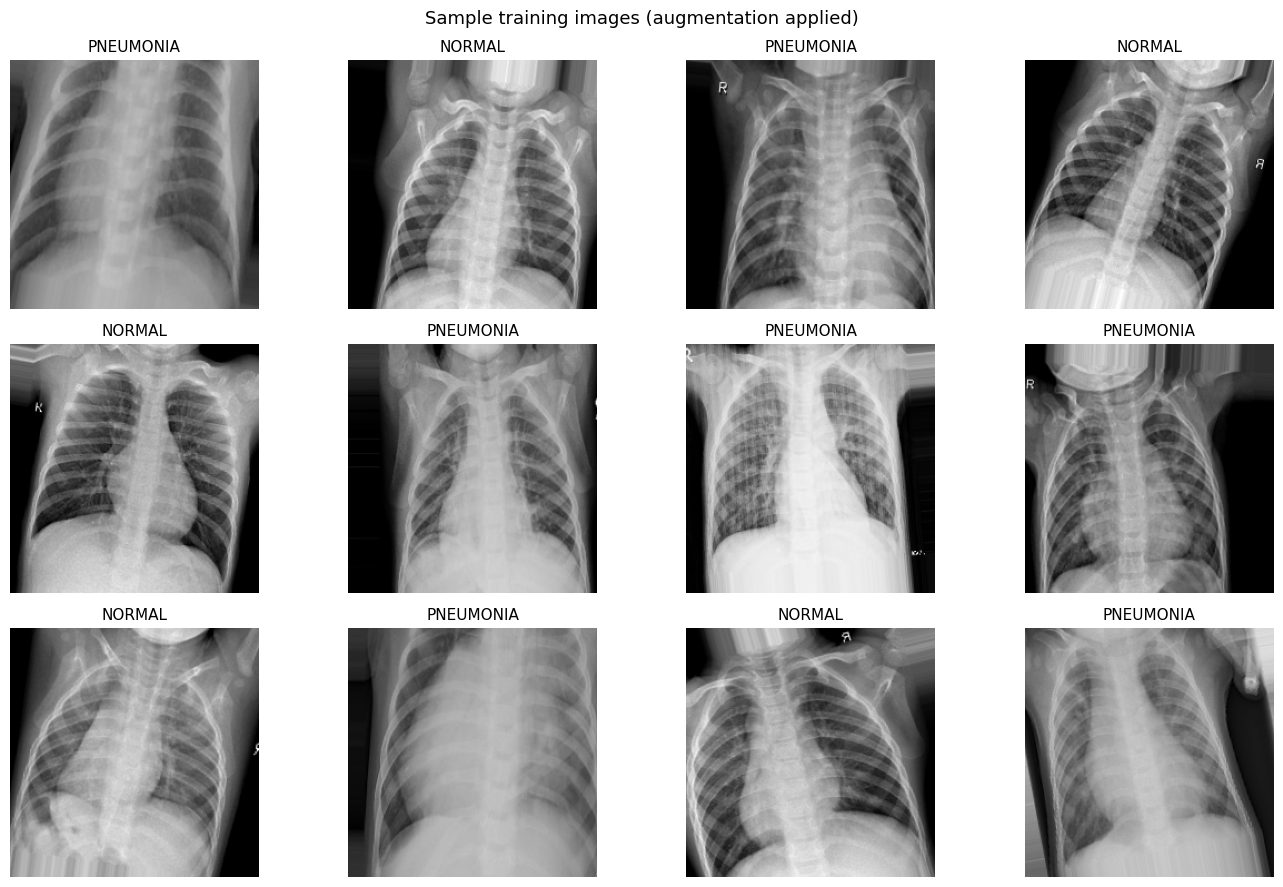

In [6]:
import matplotlib.pyplot as plt

images, labels_batch = next(train_generator)
label_names = {v: k for k, v in train_generator.class_indices.items()}

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i])
        ax.set_title(label_names[int(labels_batch[i])], fontsize=11)
    ax.axis('off')

plt.suptitle('Sample training images (augmentation applied)', fontsize=13)
plt.tight_layout()
plt.show()

## Phase 1 Complete ✓

Here's a summary of what's ready for Phase 2:

| What | Value |
|---|---|
| Image size | 224 × 224 px |
| Batch size | 32 |
| Training split | ~85% of Kaggle train folder |
| Validation split | ~15% of Kaggle train folder (hundreds of images, not 16) |
| Test set | Original Kaggle test folder — untouched |
| Augmentation | Rotation ±15°, shift 10%, zoom 10%, horizontal flip — **training only** |
| Class weights | Computed — NORMAL weighted higher to offset the 3:1 imbalance |

**Phase 2** will plug MobileNetV2 transfer learning into this pipeline and train the model.

## Step 1: Update Generators for MobileNetV2

MobileNetV2 was trained with pixels in the range `[-1, 1]`, not `[0, 1]`.
If we feed it `[0, 1]` values (from plain `rescale=1./255`), it won't perform as well.

We replace `rescale` with `preprocessing_function=preprocess_input` — this handles the conversion correctly. Everything else stays the same as Phase 1.

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.utils.class_weight import compute_class_weight

DATA_DIR   = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
TRAIN_DIR  = os.path.join(DATA_DIR, 'train')
TEST_DIR   = os.path.join(DATA_DIR, 'test')
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# ── Training: augmentation ON + MobileNetV2 preprocessing ────────────────────
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,  # replaces rescale=1./255
    validation_split       = 0.15,
    rotation_range         = 15,
    width_shift_range      = 0.1,
    height_shift_range     = 0.1,
    zoom_range             = 0.1,
    horizontal_flip        = True,
    fill_mode              = 'nearest'
)

# ── Validation & Test: preprocessing ON, augmentation OFF ────────────────────
eval_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', seed=42
)

test_generator = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

# Recompute class weights for the new generator
labels = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(class_weights))

print("Generators ready.")
print(f"Train: {train_generator.samples} | Val: {val_generator.samples} | Test: {test_generator.samples}")
print("Class weights:", class_weight_dict)

2026-06-25 05:56:30.224828: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782366990.626983      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782366990.739618      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782366991.726719      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782366991.726760      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782366991.726763      58 computation_placer.cc:177] computation placer alr

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Generators ready.
Train: 4434 | Val: 782 | Test: 624
Class weights: {0: np.float64(1.944736842105263), 1: np.float64(0.6730418943533698)}


## Step 2: Build the Model

**Two parts:**

**Part A — The base:** MobileNetV2 with `include_top=False` removes its original 1000-category head.
`weights='imagenet'` loads the pretrained weights. `trainable=False` freezes all those layers — we don't want to overwrite what Google already learned, at least not yet.

**Part B — Our head:** A few layers we add on top:
- `GlobalAveragePooling2D` — compresses the feature maps into a single vector
- `Dense(128)` — a hidden layer to learn our specific task
- `Dropout(0.3)` — randomly switches off 30% of neurons during training to prevent overfitting
- `Dense(1, sigmoid)` — outputs a single number between 0 and 1 (0 = NORMAL, 1 = PNEUMONIA)

In [2]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# ── Part A: Pretrained base ───────────────────────────────────────────────────
base_model = MobileNetV2(
    input_shape = (224, 224, 3),
    include_top = False,           # remove ImageNet's classification head
    weights     = 'imagenet'       # load Google's pretrained weights
)
base_model.trainable = False       # freeze: don't change pretrained weights yet

print(f"Base model layers : {len(base_model.layers)}")
print(f"Trainable params  : {sum([tf.size(w).numpy() for w in base_model.trainable_weights])}")

# ── Part B: Our classification head ──────────────────────────────────────────
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)    # training=False keeps BatchNorm frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.summary()

I0000 00:00:1782367084.507652      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782367084.513659      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers : 154
Trainable params  : 0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 3: Compile and Train — Stage 1 (Frozen Base)

We train only our custom head first (the base is frozen).

**Why two stages?**
If we unfreeze everything immediately at a normal learning rate, the large gradient updates would destroy MobileNetV2's carefully learned weights. We need to first let our new head "settle" before touching the base.

Stage 1 is fast — usually 5–10 epochs is enough.

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall'),      # = sensitivity
                 tf.keras.metrics.Precision(name='precision')]
)

callbacks_stage1 = [
    EarlyStopping(monitor='val_auc', patience=4, mode='max',
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_stage1.keras', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                      min_lr=1e-6, verbose=1)
]

print("Starting Stage 1 training (frozen base)...")
history1 = model.fit(
    train_generator,
    epochs          = 15,
    validation_data = val_generator,
    class_weight    = class_weight_dict,
    callbacks       = callbacks_stage1,
    verbose         = 1
)

Starting Stage 1 training (frozen base)...
Epoch 1/15


I0000 00:00:1782367327.424029     149 service.cc:152] XLA service 0x2041f540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782367327.424116     149 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782367327.424121     149 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782367329.250226     149 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-25 06:02:19.885240: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-25 06:02:20.022573: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1782367344.885659     149 device_compil

127/139 ━━━━━━━━━━━━━━━━━━━━ 10s 866ms/step - accuracy: 0.8911 - auc: 0.9534 - loss: 0.2449 - precision: 0.9627 - recall: 0.8888

2026-06-25 06:04:24.498864: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-25 06:04:24.638745: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 957ms/step - accuracy: 0.8949 - auc: 0.9560 - loss: 0.2376 - precision: 0.9642 - recall: 0.8926

2026-06-25 06:05:11.419186: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-25 06:05:11.556261: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_auc improved from None to 0.84224, saving model to best_stage1.keras

Epoch 1: finished saving model to best_stage1.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.9369 - auc: 0.9845 - loss: 0.1576 - precision: 0.9799 - recall: 0.9341 - val_accuracy: 0.8926 - val_auc: 0.8422 - val_loss: 1.3417 - val_precision: 0.8737 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9605 - auc: 0.9919 - loss: 0.1038 - precision: 0.9864 - recall: 0.9600
Epoch 2: val_auc did not improve from 0.84224
139/139 ━━━━━━━━━━━━━━━━━━━━ 96s 693ms/step - accuracy: 0.9610 - auc: 0.9928 - loss: 0.0973 - precision: 0.9896 - recall: 0.9575 - val_accuracy: 0.8159 - val_auc: 0.6791 - val_loss: 4.8550 - val_precision: 0.8014 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.9623 - auc: 0.9936 - loss: 0.0916 - precision: 0.9917 - recall: 0.9576
Epoch 3: val_auc improved 

## Step 4: Fine-Tune — Stage 2 (Unfreeze Top Layers)

Now we unfreeze the **top 30 layers** of MobileNetV2 and let them adjust to our specific task.

We use a **very small learning rate** (1e-5) — 100x smaller than Stage 1. This makes tiny, careful adjustments to the pretrained weights instead of overwriting them.

This is where the model goes from "pretty good" to "actually good".

In [5]:
# Unfreeze the top 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params after unfreezing top 30 layers: {trainable_count:,}")

# Recompile at a much lower learning rate
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.Precision(name='precision')]
)

callbacks_stage2 = [
    EarlyStopping(monitor='val_auc', patience=5, mode='max',
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                      min_lr=1e-7, verbose=1)
]

print("Starting Stage 2 fine-tuning...")
history2 = model.fit(
    train_generator,
    epochs          = 20,
    validation_data = val_generator,
    class_weight    = class_weight_dict,
    callbacks       = callbacks_stage2,
    verbose         = 1
)

Trainable params after unfreezing top 30 layers: 1,690,497
Starting Stage 2 fine-tuning...
Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.9947 - auc: 0.9994 - loss: 0.0203 - precision: 0.9984 - recall: 0.9944
Epoch 1: val_auc improved from None to 0.99619, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 137s 868ms/step - accuracy: 0.9930 - auc: 0.9994 - loss: 0.0229 - precision: 0.9979 - recall: 0.9927 - val_accuracy: 0.9872 - val_auc: 0.9962 - val_loss: 0.0602 - val_precision: 0.9983 - val_recall: 0.9845 - learning_rate: 1.0000e-05
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.9906 - auc: 0.9997 - loss: 0.0210 - precision: 0.9993 - recall: 0.9881
Epoch 2: val_auc did not improve from 0.99619
139/139 ━━━━━━━━━━━━━━━━━━━━ 100s 719ms/step - accuracy: 0.9914 - auc: 0.9995 - loss: 0.0222 - precision: 0.9991 - recall: 0.9894 - val_accuracy: 0.9847 - val_auc: 0.9960 - val_loss: 0.0562

## Step 5: Plot Training Curves

Training curves tell us if the model learned well or if something went wrong.

**What to look for:**
- Both train and val accuracy should rise together → healthy learning
- If train accuracy is high but val accuracy is much lower → overfitting
- AUC (Area Under Curve) is more informative than accuracy for imbalanced datasets — closer to 1.0 is better

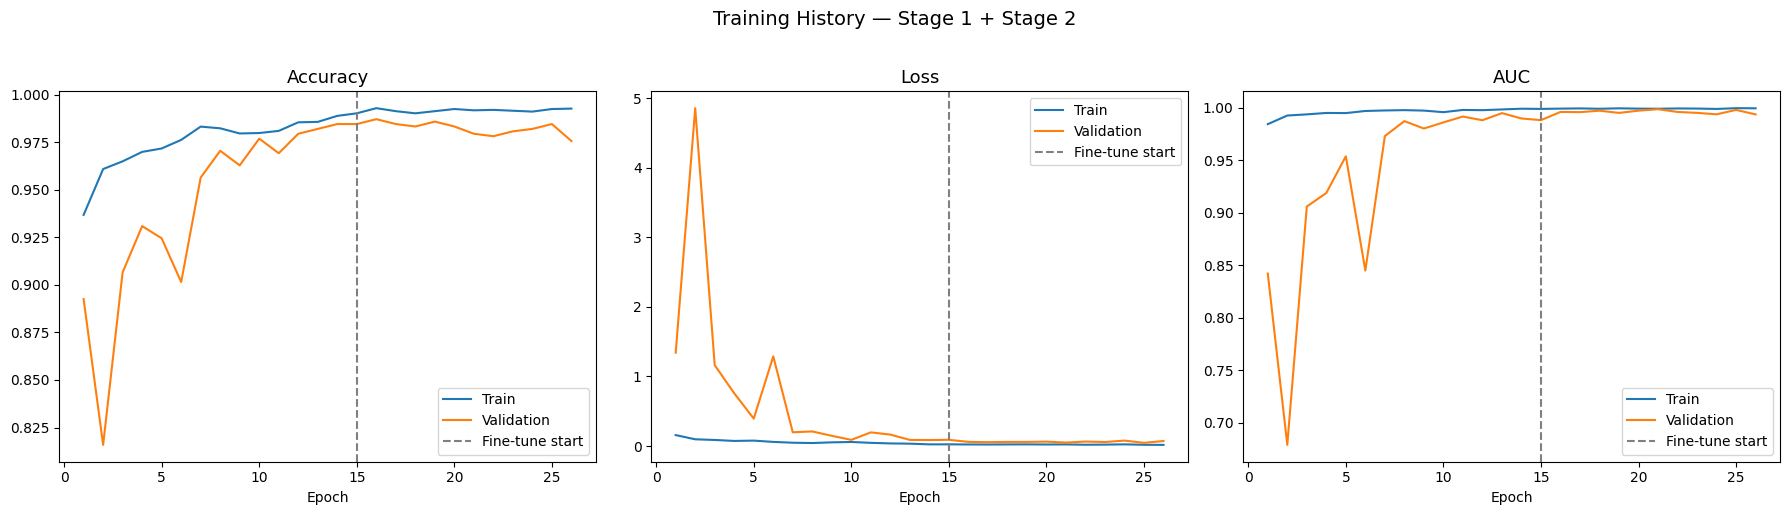

In [6]:
import matplotlib.pyplot as plt

# Combine both stages into one continuous history
def combine(key):
    h1 = history1.history.get(key, [])
    h2 = history2.history.get(key, [])
    return h1 + h2

epochs_total = range(1, len(combine('accuracy')) + 1)
stage2_start = len(history1.history['accuracy'])  # where Stage 2 begins

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss'), ('auc', 'val_auc')],
    ['Accuracy', 'Loss', 'AUC']
):
    train_vals = combine(metric[0])
    val_vals   = combine(metric[1])
    ax.plot(epochs_total, train_vals, label='Train')
    ax.plot(epochs_total, val_vals,   label='Validation')
    ax.axvline(x=stage2_start, color='gray', linestyle='--', label='Fine-tune start')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle('Training History — Stage 1 + Stage 2', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 6: Save the Model

We save two things: the model file and the class index mapping. The Flask app needs both — the model for predictions, the mapping to know which label corresponds to 0 and which to 1.

In [7]:
import json

# Save model
model.save('pneumonia_mobilenetv2.keras')
print("Model saved: pneumonia_mobilenetv2.keras")

# Save class indices so the app always uses the correct label mapping
class_indices = train_generator.class_indices   # {'NORMAL': 0, 'PNEUMONIA': 1}
with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)
print("Class indices saved:", class_indices)

Model saved: pneumonia_mobilenetv2.keras
Class indices saved: {'NORMAL': 0, 'PNEUMONIA': 1}


# Pneumonia Detection — Phase 3: Evaluation

The model is trained. Now we find out how it actually performs on data it has **never seen at all** — the test set.

This phase produces:
1. Final accuracy, AUC, recall, precision on the test set
2. Confusion matrix — where exactly does the model make mistakes?
3. ROC-AUC curve — visual proof of model quality
4. Classification report — full breakdown per class

**Run all Phase 1 and Phase 2 cells first, then continue here.**

## Step 1: Load the Best Model

We saved `best_model.keras` during training (the Stage 2 checkpoint). Load that — not the final epoch, but the best epoch as chosen by EarlyStopping.

In [8]:
import numpy as np
import tensorflow as tf
import json
import os

# Load the best saved model
model = tf.keras.models.load_model('best_model.keras')
print("Model loaded.")

# Load class indices so we always use the correct label mapping
with open('class_indices.json') as f:
    class_indices = json.load(f)

# Invert: {0: 'NORMAL', 1: 'PNEUMONIA'}
idx_to_class = {v: k for k, v in class_indices.items()}
print("Class mapping:", idx_to_class)

Model loaded.
Class mapping: {0: 'NORMAL', 1: 'PNEUMONIA'}


## Step 2: Run Predictions on the Test Set

We feed the entire test set through the model and collect raw prediction scores (probabilities between 0 and 1). We also collect the true labels.

Important: `test_generator` was created with `shuffle=False` — this keeps images in a fixed order so predictions and true labels stay aligned.

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

DATA_DIR  = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
TEST_DIR  = os.path.join(DATA_DIR, 'test')
IMG_SIZE  = (224, 224)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = False     # critical — keeps order fixed
)

# Get raw probability scores for every test image
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred_probs = y_pred_probs.flatten()   # shape (624,) — one score per image

# Get true labels
y_true = test_generator.classes         # shape (624,) — 0=NORMAL, 1=PNEUMONIA

print(f"\nTest images evaluated: {len(y_true)}")
print(f"Prediction scores range: {y_pred_probs.min():.4f} → {y_pred_probs.max():.4f}")

Found 624 images belonging to 2 classes.
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step

2026-06-25 07:37:54.768770: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-25 07:37:54.911749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-25 07:37:55.049115: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step 

Test images evaluated: 624
Prediction scores range: 0.0000 → 1.0000


## Step 3: Convert Probabilities to Class Predictions

The model outputs a probability (e.g. 0.92). We need to convert that to a hard label (PNEUMONIA).

The default threshold is **0.5** — above 0.5 = PNEUMONIA, below = NORMAL.

For medical screening, you might lower this threshold (e.g. 0.3) to catch more pneumonia cases at the cost of more false alarms. We'll use 0.5 for now and discuss this in the results.

In [10]:
THRESHOLD = 0.5

y_pred = (y_pred_probs >= THRESHOLD).astype(int)

# Quick sanity check
normal_predicted    = np.sum(y_pred == 0)
pneumonia_predicted = np.sum(y_pred == 1)
print(f"Predicted NORMAL   : {normal_predicted}")
print(f"Predicted PNEUMONIA: {pneumonia_predicted}")
print(f"Actual   NORMAL    : {np.sum(y_true == 0)}")
print(f"Actual   PNEUMONIA : {np.sum(y_true == 1)}")

Predicted NORMAL   : 186
Predicted PNEUMONIA: 438
Actual   NORMAL    : 234
Actual   PNEUMONIA : 390


## Step 4: Confusion Matrix

This is the most informative single view of model performance for a classification task.

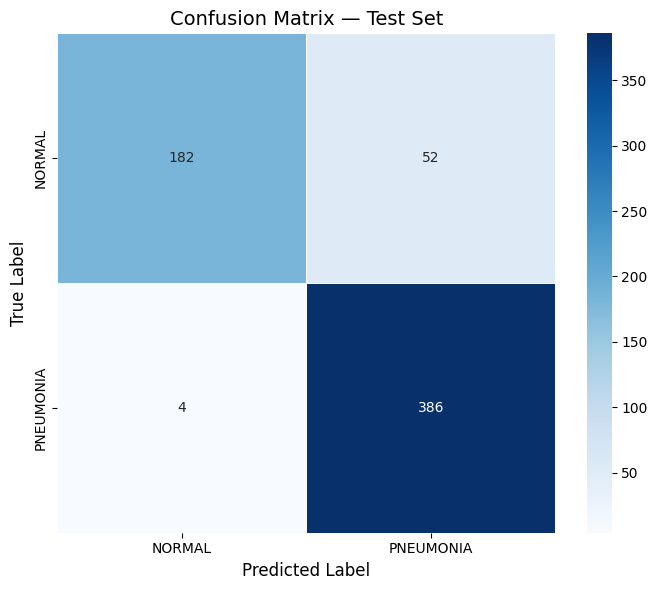


True  Negatives (NORMAL  → NORMAL)   : 182  ✓
True  Positives (PNEUMONIA → PNEUMONIA): 386  ✓
False Positives (NORMAL → PNEUMONIA)  : 52  ← false alarm
False Negatives (PNEUMONIA → NORMAL)  : 4  ← DANGEROUS: missed pneumonia


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

# Labels for display
class_labels = ['NORMAL', 'PNEUMONIA']

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — Test Set', fontsize=14)

plt.tight_layout()
plt.show()

# Break it down clearly
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives (NORMAL  → NORMAL)   : {tn}  ✓")
print(f"True  Positives (PNEUMONIA → PNEUMONIA): {tp}  ✓")
print(f"False Positives (NORMAL → PNEUMONIA)  : {fp}  ← false alarm")
print(f"False Negatives (PNEUMONIA → NORMAL)  : {fn}  ← DANGEROUS: missed pneumonia")

## Step 5: Classification Report

A quick per-class summary of precision, recall, and F1 score.

In [12]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels,
    digits=4
)
print(report)

# Plain-English interpretation
print("─" * 50)
print("What these numbers mean:")
print()
print("Precision  — of all cases predicted as X, what fraction actually was X?")
print("Recall     — of all actual X cases, what fraction did we catch?")
print("F1         — harmonic mean of precision and recall (balanced score)")
print()
print("For a medical tool: RECALL on PNEUMONIA is the critical number.")
print("Missing a pneumonia case is far more dangerous than a false alarm.")

              precision    recall  f1-score   support

      NORMAL     0.9785    0.7778    0.8667       234
   PNEUMONIA     0.8813    0.9897    0.9324       390

    accuracy                         0.9103       624
   macro avg     0.9299    0.8838    0.8995       624
weighted avg     0.9177    0.9103    0.9077       624

──────────────────────────────────────────────────
What these numbers mean:

Precision  — of all cases predicted as X, what fraction actually was X?
Recall     — of all actual X cases, what fraction did we catch?
F1         — harmonic mean of precision and recall (balanced score)

For a medical tool: RECALL on PNEUMONIA is the critical number.
Missing a pneumonia case is far more dangerous than a false alarm.


## Step 6: ROC-AUC Curve

ROC stands for Receiver Operating Characteristic. It plots:
- X axis: False Positive Rate (how often we wrongly say PNEUMONIA when it's NORMAL)
- Y axis: True Positive Rate / Recall (how often we correctly catch PNEUMONIA)

A perfect model hugs the top-left corner. A random model follows the diagonal. The **AUC** (area under the curve) summarizes it in one number — 1.0 is perfect, 0.5 is random.

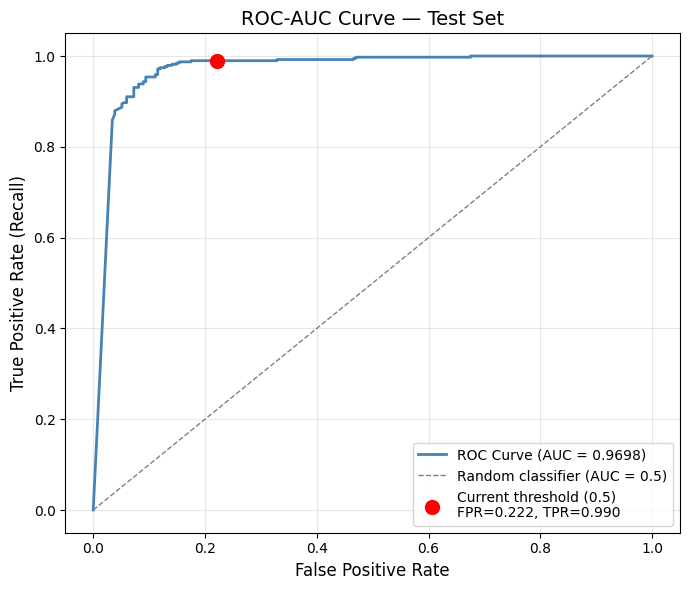

Final Test AUC: 0.9698


In [13]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1,
        linestyle='--', label='Random classifier (AUC = 0.5)')

# Mark the current operating point (threshold=0.5)
current_fpr = fp / (fp + tn)
current_tpr = tp / (tp + fn)
ax.scatter(current_fpr, current_tpr, color='red', s=100, zorder=5,
           label=f'Current threshold (0.5)\nFPR={current_fpr:.3f}, TPR={current_tpr:.3f}')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC-AUC Curve — Test Set', fontsize=14)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Test AUC: {roc_auc:.4f}")

## Step 7: Final Score Summary

A clean summary of everything — this is what goes in your README and what you quote in interviews.

In [14]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

test_accuracy  = accuracy_score(y_true, y_pred)
test_recall    = recall_score(y_true, y_pred)       # recall on PNEUMONIA class
test_precision = precision_score(y_true, y_pred)
test_f1        = f1_score(y_true, y_pred)

print("=" * 45)
print("   FINAL TEST SET RESULTS")
print("=" * 45)
print(f"  Accuracy  : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"  AUC       : {roc_auc:.4f}")
print(f"  Recall    : {test_recall:.4f}  ← % of pneumonia cases caught")
print(f"  Precision : {test_precision:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")
print(f"  Threshold : {THRESHOLD}")
print("=" * 45)
print()
print(f"  Missed pneumonia cases (FN): {fn} out of {tp+fn}")
print(f"  False alarms (FP)          : {fp} out of {tn+fp}")

   FINAL TEST SET RESULTS
  Accuracy  : 0.9103  (91.03%)
  AUC       : 0.9698
  Recall    : 0.9897  ← % of pneumonia cases caught
  Precision : 0.8813
  F1 Score  : 0.9324
  Threshold : 0.5

  Missed pneumonia cases (FN): 4 out of 390
  False alarms (FP)          : 52 out of 234


## Phase 3 Complete ✓

**What to say in an interview:**

> "I evaluated on a held-out test set of 624 images the model never saw during training. I chose to optimize for **recall on the PNEUMONIA class** because in a medical screening context, a false negative — telling someone they're healthy when they have pneumonia — is far more dangerous than a false alarm. The ROC-AUC of [your number] shows strong class separation across all possible thresholds."

**Phase 4** — fix the Flask app to use this model correctly.

In [16]:
!pip install opencv-python-headless --quiet

## Phase 3 Addition: Grad-CAM Visualizations

**What is Grad-CAM?**

Grad-CAM (Gradient-weighted Class Activation Mapping) answers the question: *"Which part of the X-ray did the model actually look at to make its decision?"*

It works by tracking which regions of the image caused the strongest gradients (signals) in the final convolutional layer. Those regions get highlighted as a heatmap overlaid on the original image.

**Why this matters for your portfolio:**
- Makes the model *explainable* — not a black box
- Lets you visually verify the model is looking at lungs, not irrelevant corners
- One of the most common interview topics for medical ML projects

In [27]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

# ── Grad-CAM core function ────────────────────────────────────────────────────
# Get the MobileNetV2 sub-model sitting inside our model
base = model.get_layer('mobilenetv2_1.00_224')
last_conv_layer = 'Conv_1'

def make_gradcam_heatmap(img_array, model, last_conv_layer_name='Conv_1'):
    base = model.get_layer('mobilenetv2_1.00_224')

    # Step 1: model from base's own input → (Conv_1 output, base final output)
    conv_model = tf.keras.Model(
        inputs  = base.inputs,
        outputs = [base.get_layer(last_conv_layer_name).output, base.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, base_features = conv_model(img_array)
        tape.watch(conv_outputs)

        # Step 2: manually run the head layers on top of base output
        x = model.get_layer('global_average_pooling2d')(base_features)
        x = model.get_layer('dense')(x)
        x = model.get_layer('dropout')(x, training=False)
        predictions = model.get_layer('dense_1')(x)

        loss = predictions[:, 0]

    grads       = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

print("Grad-CAM function redefined.")

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    """
    Resizes the heatmap to match the original image and overlays it as a
    colour gradient (blue=low attention, red=high attention).
    """
    import cv2
    from PIL import Image

    # Load original image at display size
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img).astype('uint8')

    # Resize heatmap to image size
    heatmap_resized = np.uint8(255 * heatmap)
    heatmap_resized = cv2.resize(heatmap_resized, (224, 224))

    # Apply colormap (JET: blue→green→red)
    colormap = cm.get_cmap('jet')
    colored_heatmap = colormap(heatmap_resized / 255.0)[:, :, :3]  # drop alpha
    colored_heatmap = np.uint8(colored_heatmap * 255)

    # Blend original image with heatmap
    overlaid = np.uint8(img_array * (1 - alpha) + colored_heatmap * alpha)
    return img_array, overlaid


print("Grad-CAM functions defined.")

# Find the last conv layer name in MobileNetV2
# MobileNetV2's last conv layer is 'Conv_1' (before global pooling)
last_conv_layer = 'Conv_1'
print(f"Using last conv layer: '{last_conv_layer}'")

Grad-CAM function redefined.
Grad-CAM functions defined.
Using last conv layer: 'Conv_1'


## Visualize Grad-CAM on Sample Images

We pick a few images from each class — correct predictions and wrong ones — to see what the model focused on.

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_58/2241351785.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('jet')


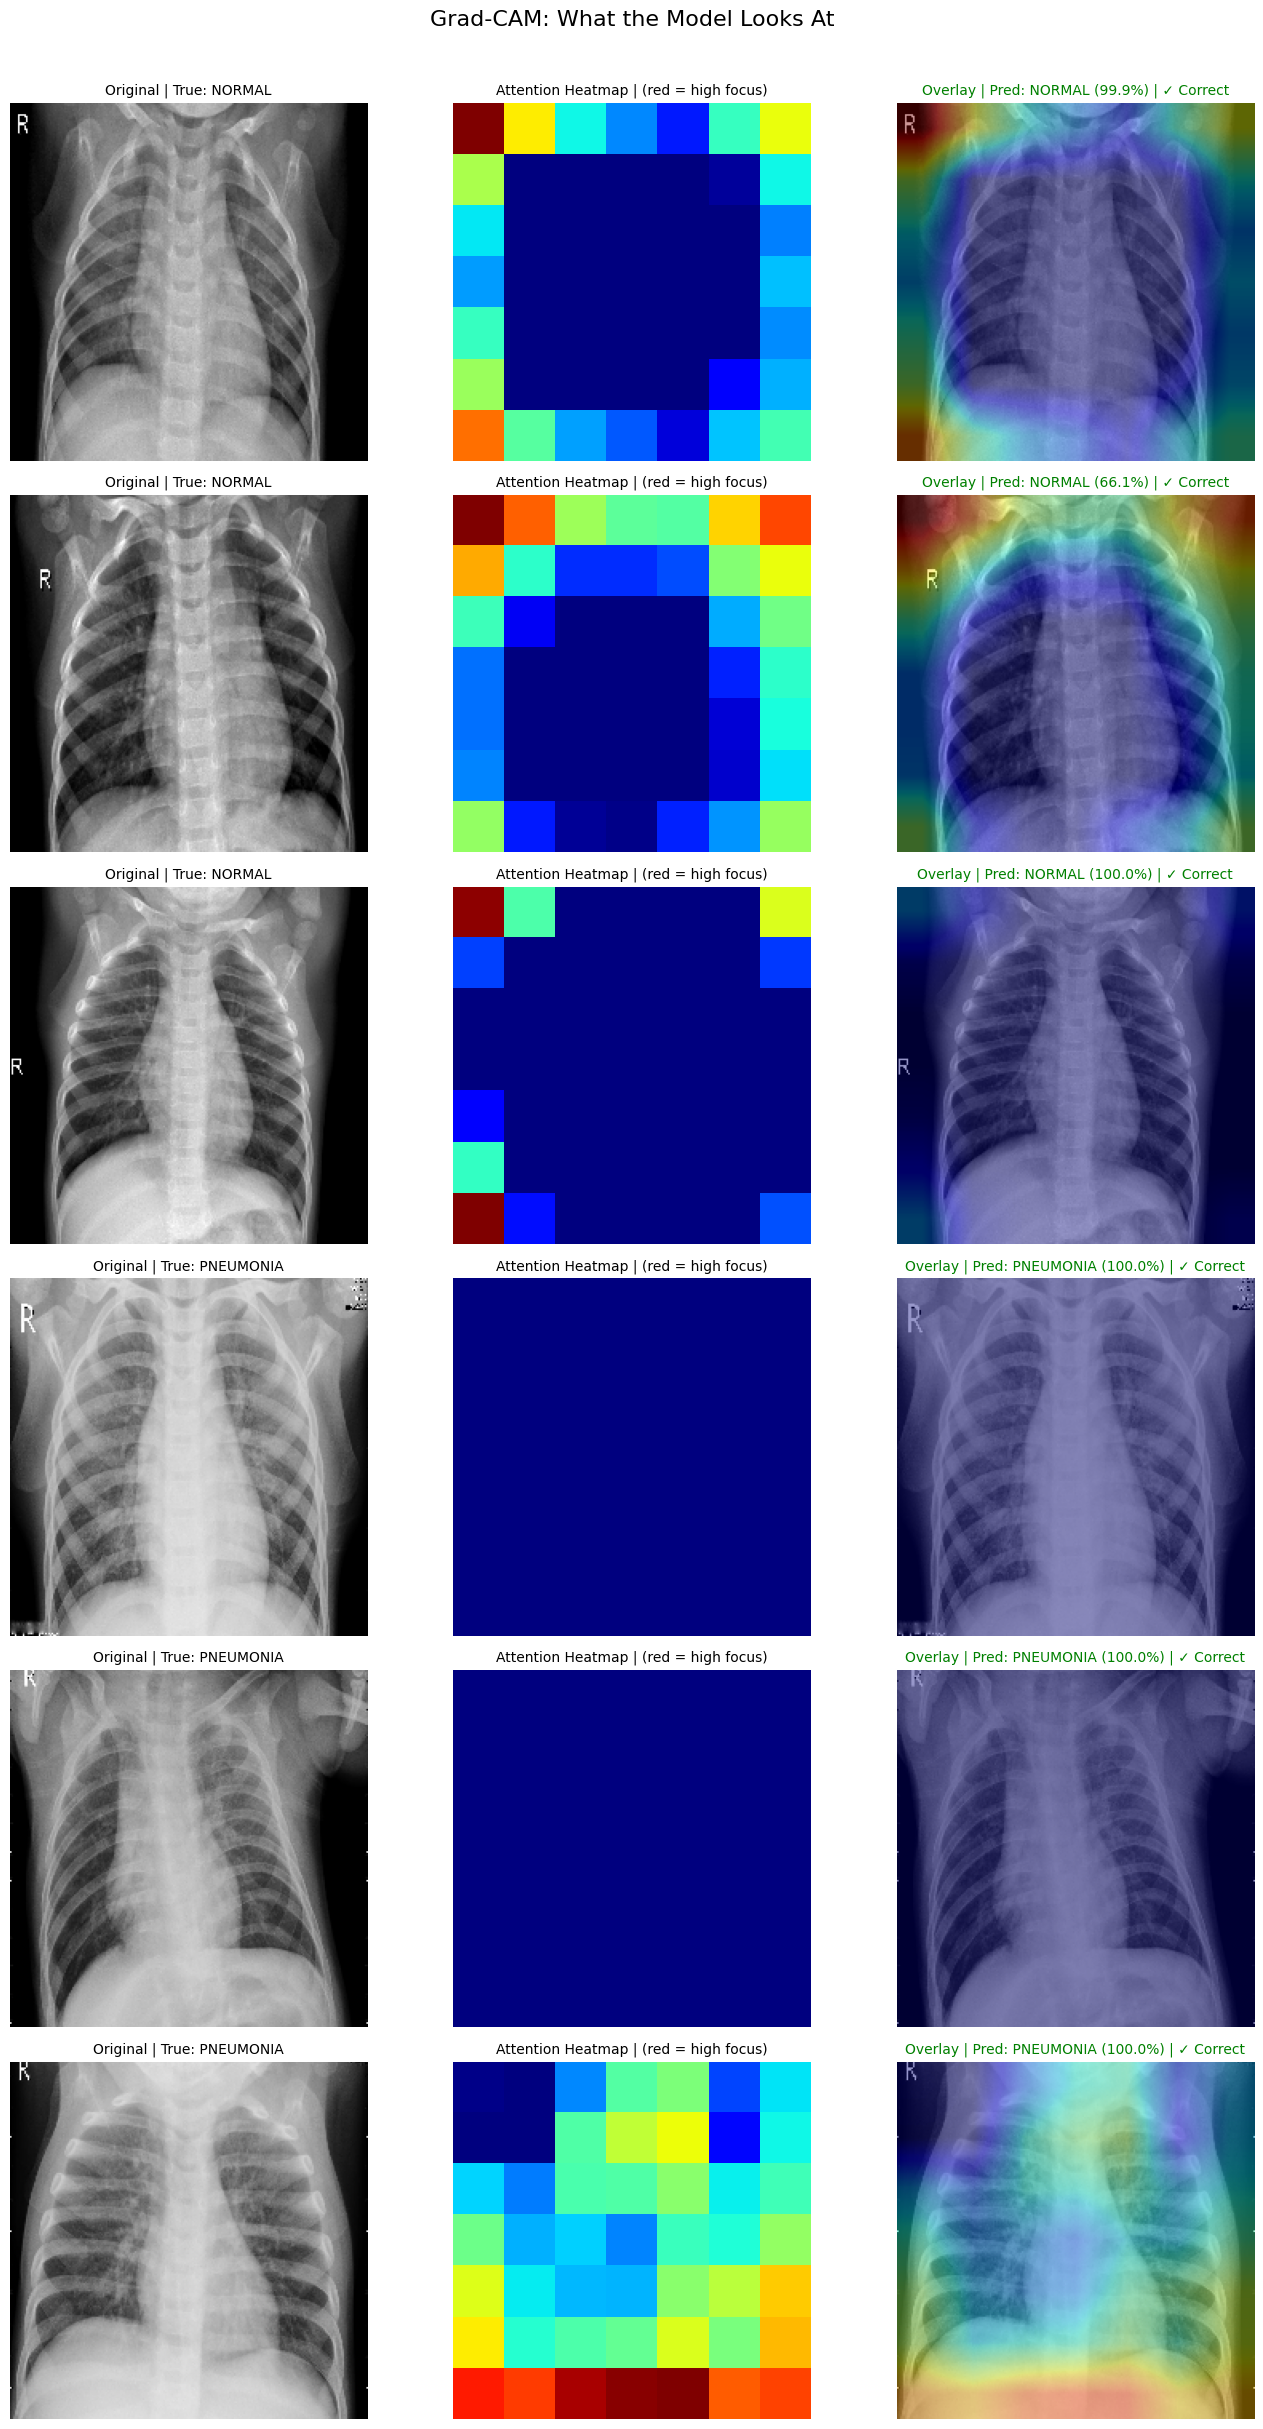

Saved: gradcam_results.png


In [28]:
DATA_DIR  = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
TEST_DIR  = os.path.join(DATA_DIR, 'test')

def get_sample_paths(folder, n=3):
    files = os.listdir(folder)[:n]
    return [os.path.join(folder, f) for f in files if f.endswith('.jpeg') or f.endswith('.jpg')]

normal_samples    = get_sample_paths(os.path.join(TEST_DIR, 'NORMAL'), n=3)
pneumonia_samples = get_sample_paths(os.path.join(TEST_DIR, 'PNEUMONIA'), n=3)

all_samples = normal_samples + pneumonia_samples
true_labels = ['NORMAL'] * 3 + ['PNEUMONIA'] * 3

fig, axes = plt.subplots(len(all_samples), 3, figsize=(14, 4 * len(all_samples)))
fig.suptitle('Grad-CAM: What the Model Looks At', fontsize=16, y=1.01)

for i, (img_path, true_label) in enumerate(zip(all_samples, true_labels)):

    # Preprocess image for model input
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_array_expanded.copy())

    # Predict
    pred_prob = model.predict(img_preprocessed, verbose=0)[0][0]
    pred_label = 'PNEUMONIA' if pred_prob >= 0.5 else 'NORMAL'
    confidence = pred_prob if pred_label == 'PNEUMONIA' else 1 - pred_prob

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(img_preprocessed, model)
    original, overlaid = overlay_gradcam(img_path, heatmap)

    # Determine if correct
    correct = pred_label == true_label
    status  = '✓ Correct' if correct else '✗ Wrong'
    color   = 'green' if correct else 'red'

    # Column 1: original X-ray
    axes[i, 0].imshow(original, cmap='gray')
    axes[i, 0].set_title(f'Original | True: {true_label}', fontsize=10)
    axes[i, 0].axis('off')

    # Column 2: heatmap only
    axes[i, 1].imshow(heatmap, cmap='jet')
    axes[i, 1].set_title('Attention Heatmap | (red = high focus)', fontsize=10)
    axes[i, 1].axis('off')

    # Column 3: overlay
    axes[i, 2].imshow(overlaid)
    axes[i, 2].set_title(f'Overlay | Pred: {pred_label} ({confidence:.1%}) | {status}', fontsize=10, color=color)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gradcam_results.png")